Imports

In [3]:
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

Create Filtered CSV For EDA

In [4]:
# Notebook-friendly paths (no __file__ in Jupyter)
ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
TWEETS_PATH = DATA_DIR / 'tweets.txt'
EMOJI_PATH = DATA_DIR / 'emoji.txt'
OUT_CSV = DATA_DIR / 'filtered_tweets.csv'

# Remove all mentions
MENTION_RE = re.compile(r'@\w+')
URL_RE = re.compile(r'https?://\S+|www\.\S+', re.I)
# Remove leading "rt :" retweet prefix
RT_PREFIX_RE = re.compile(r'^\s*rt\s*:\s*', re.I)
SPACE_RE = re.compile(r'\s+')


def clean_tweet(text: str) -> str:
    text = URL_RE.sub('', text)
    text = MENTION_RE.sub('', text)
    text = SPACE_RE.sub(' ', text).strip()
    text = RT_PREFIX_RE.sub('', text)
    return text.strip()


def word_metrics(text: str) -> tuple[int, float]:
    """Whitespace token count and mean token length (chars)."""
    words = text.split()
    n = len(words)
    if not n:
        return 0, 0.0
    return n, sum(len(w) for w in words) / n


rows = []
with open(TWEETS_PATH, encoding='utf-8', errors='replace') as tf, open(
    EMOJI_PATH, encoding='utf-8', errors='replace'
) as ef:
    for line_no, (tweet_line, emoji_line) in enumerate(zip(tf, ef), start=1):
        raw = tweet_line.rstrip('\n\r')
        emoji_label = emoji_line.strip()
        mention_count = raw.count('@')
        is_retweet = raw.lstrip().lower().startswith('rt @')
        tweet_body = clean_tweet(raw)
        char_count = len(tweet_body)
        has_question_mark = '?' in tweet_body
        has_exclamation_mark = '!' in tweet_body
        has_hash = '#' in tweet_body
        capital_letter_count = sum(1 for c in tweet_body if c.isupper())
        word_count, avg_word_length = word_metrics(tweet_body)
        rows.append(
            {
                'LINE_NUM': line_no,
                'TWEET': tweet_body,
                'EMOJI': emoji_label,
                'CHAR_COUNT': char_count,
                'WORD_COUNT': word_count,
                'AVG_WORD_LENGTH': avg_word_length,
                'CAPITAL_LETTER_COUNT': capital_letter_count,
                'MENTION_COUNT': mention_count,
                'HAS_QUESTION_MARK': has_question_mark,
                'HAS_EXCLAMATION_MARK': has_exclamation_mark,
                'HAS_HASH': has_hash,
                'IS_RETWEET': is_retweet,
            }
        )

df = pd.DataFrame(rows)

# Remove dupe tweets
df = df[df['TWEET'].duplicated(keep=False)]
df.to_csv(OUT_CSV, index=False)

print(f'Wrote {len(df)} rows to {OUT_CSV}')

Wrote 100103 rows to c:\Users\avina\Emojithon\data\filtered_tweets.csv


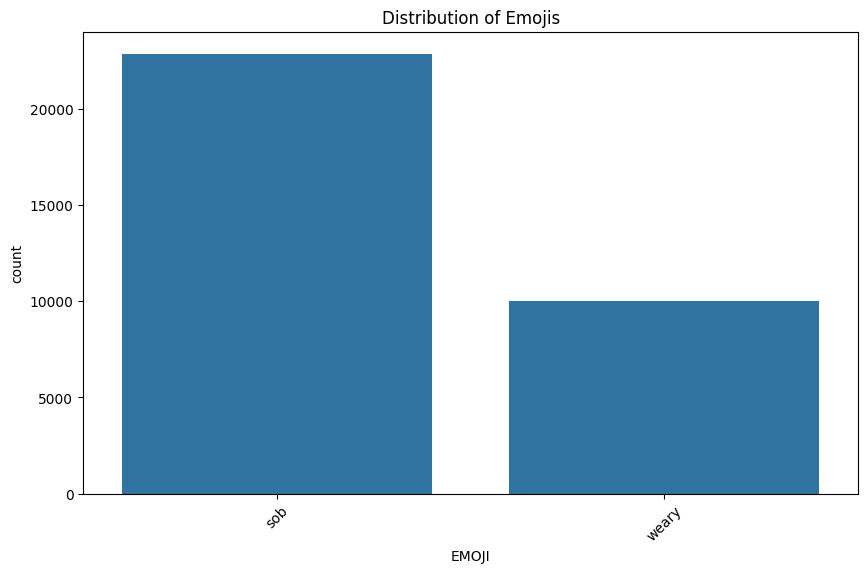

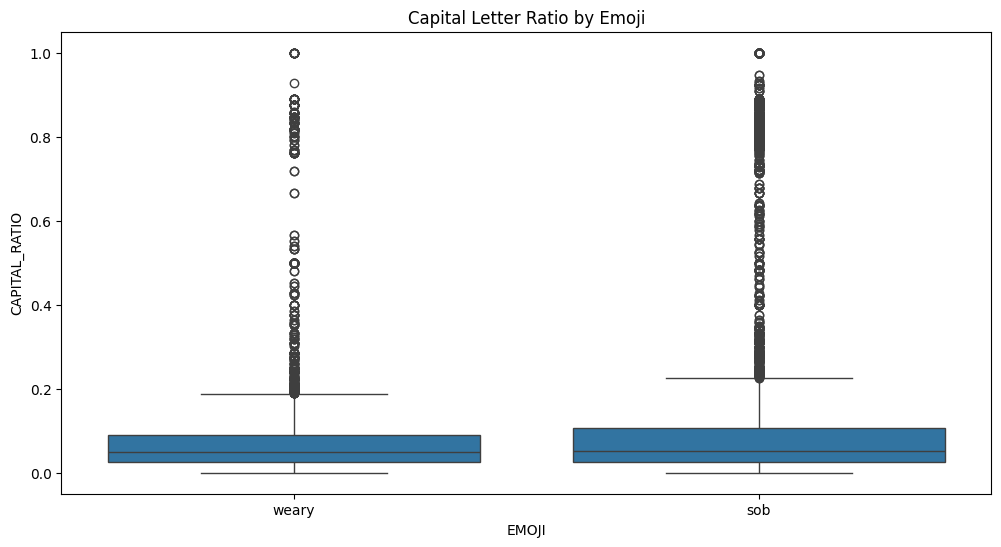

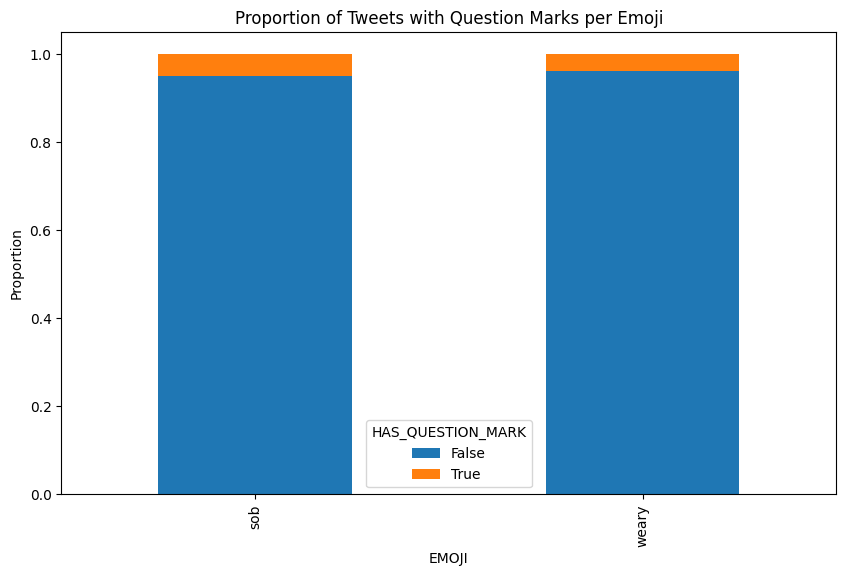

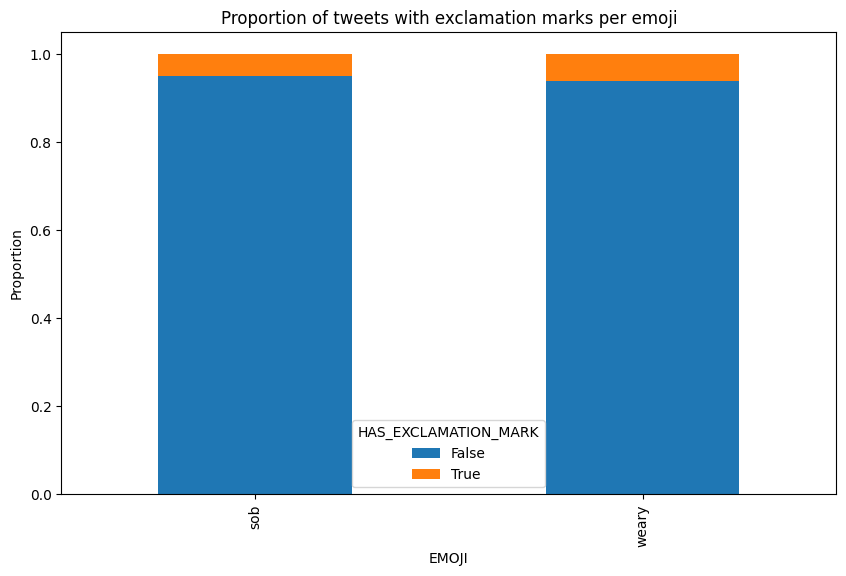

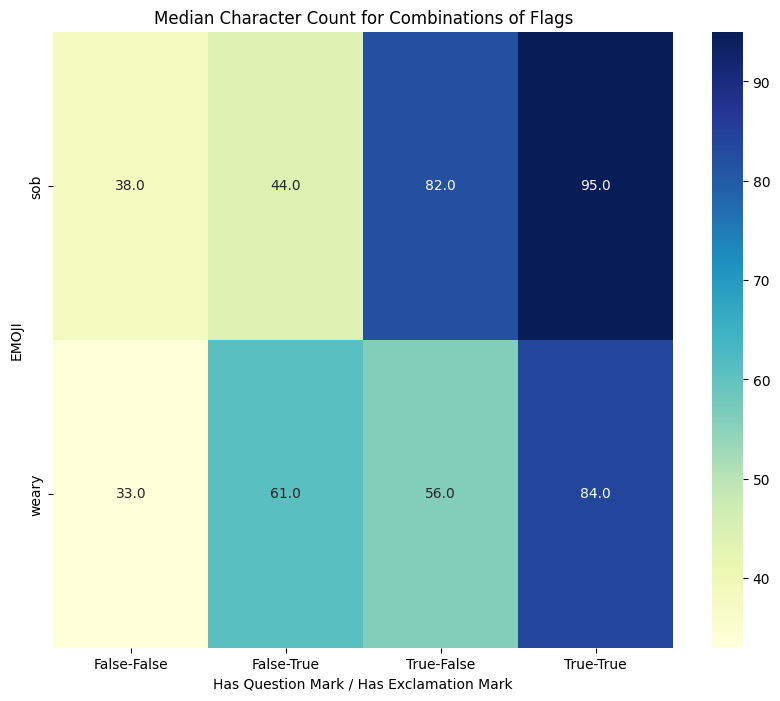

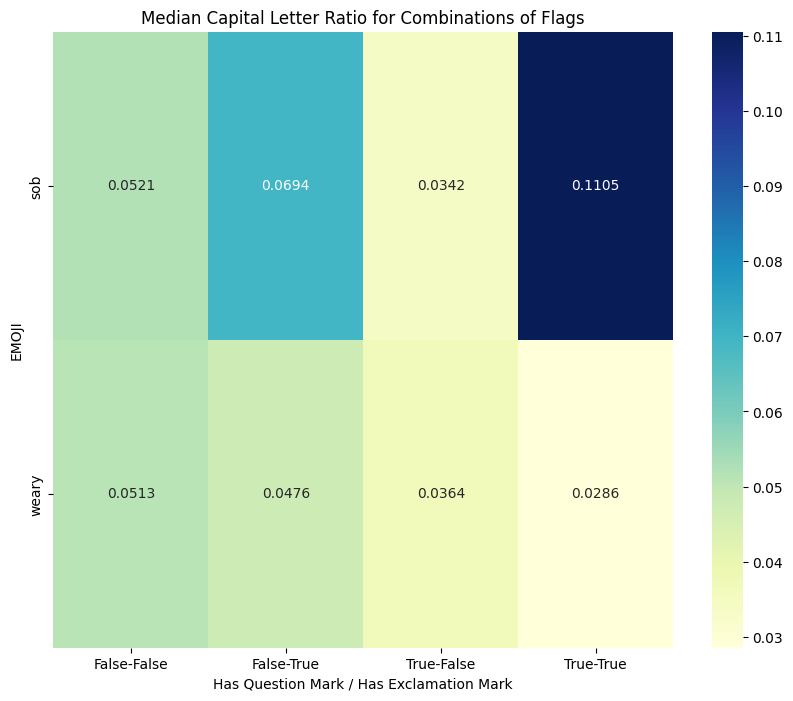

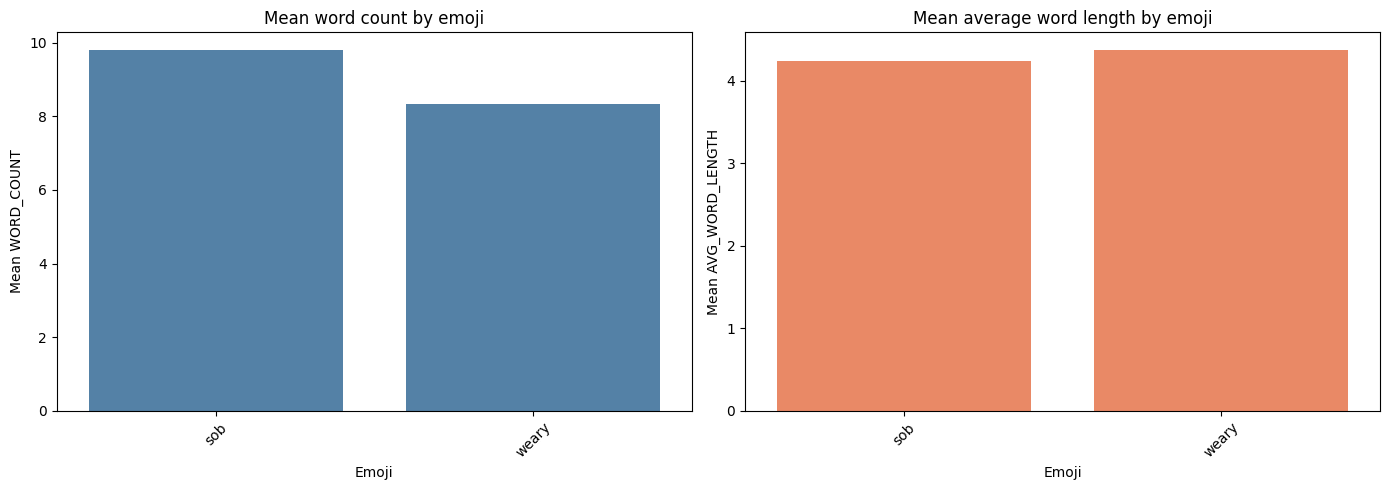

In [5]:
TRAIN_CSV = DATA_DIR / 'filtered_tweets.csv'

df = pd.read_csv(TRAIN_CSV)

# Drop unimportant features
df = df.drop(columns=['LINE_NUM'])

# 
df = df[df['EMOJI'].isin(['sob', 'weary'])]

# Calculate capital ratio
df['CAPITAL_RATIO'] = df['CAPITAL_LETTER_COUNT'] / df['CHAR_COUNT']

# Target Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='EMOJI', order=df['EMOJI'].value_counts().index)
plt.title('Distribution of Emojis')
plt.xticks(rotation=45)
plt.show()

# Capital Letters vs Emoji (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='EMOJI', y='CAPITAL_RATIO')
plt.title('Capital Letter Ratio by Emoji')
plt.show()

# Question Marks vs Emoji (Cross-tabulation)
crosstab = pd.crosstab(df['EMOJI'], df['HAS_QUESTION_MARK'], normalize='index')
crosstab.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Proportion of Tweets with Question Marks per Emoji')
plt.ylabel('Proportion')
plt.show()

# Exclamation marks vs Emoji (cross-tabulation)
crosstab = pd.crosstab(df['EMOJI'], df['HAS_EXCLAMATION_MARK'], normalize='index')
crosstab.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Proportion of tweets with exclamation marks per emoji')
plt.ylabel('Proportion')
plt.show()


# Character Count Distribution
pivot_table = df.pivot_table(
    values='CHAR_COUNT', 
    index='EMOJI', 
    columns=['HAS_QUESTION_MARK', 'HAS_EXCLAMATION_MARK'], 
    aggfunc='median'
)

# Heat map of character count for combinations of flags
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt=".1f")
plt.title('Median Character Count for Combinations of Flags')
plt.xlabel('Has Question Mark / Has Exclamation Mark')
plt.show()

pivot_table = df.pivot_table(
    values='CAPITAL_RATIO', 
    index='EMOJI', 
    columns=['HAS_QUESTION_MARK', 'HAS_EXCLAMATION_MARK'], 
    aggfunc='median'
)

# Heat map of capital letter ratio for combinations of flags
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt=".4f")
plt.title('Median Capital Letter Ratio for Combinations of Flags')
plt.xlabel('Has Question Mark / Has Exclamation Mark')
plt.show()


# Bar charts: emoji (x) vs mean word count / mean average word length (y)
emoji_order_words = df['EMOJI'].value_counts().index.tolist()
word_by_emoji = (
    df.groupby('EMOJI', observed=False)[['WORD_COUNT', 'AVG_WORD_LENGTH']]
    .mean()
    .reindex(emoji_order_words)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    data=word_by_emoji,
    x='EMOJI',
    y='WORD_COUNT',
    order=emoji_order_words,
    ax=axes[0],
    color='steelblue',
)
axes[0].set_title('Mean word count by emoji')
axes[0].set_xlabel('Emoji')
axes[0].set_ylabel('Mean WORD_COUNT')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(
    data=word_by_emoji,
    x='EMOJI',
    y='AVG_WORD_LENGTH',
    order=emoji_order_words,
    ax=axes[1],
    color='coral',
)
axes[1].set_title('Mean average word length by emoji')
axes[1].set_xlabel('Emoji')
axes[1].set_ylabel('Mean AVG_WORD_LENGTH')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [6]:
df_shuffled = df.sample(frac=1, random_state=42)

# Limit to 10,000 rows per emoji
df_balanced = df_shuffled.groupby('EMOJI').head(10000)
df_balanced = df_balanced.reset_index(drop=True)

print("New Emoji Distribution:")
print(df_balanced['EMOJI'].value_counts())

New Emoji Distribution:
EMOJI
sob      10000
weary    10000
Name: count, dtype: int64


In [7]:
import re
df = df_balanced # Switch to balanced

_token_re = re.compile(r"[a-z0-9']+", re.I)


def tweet_word_tokens(text) -> list[str]:
    return [t for t in _token_re.findall(str(text).lower()) if len(t) >= 3]


_all_tokens: list[str] = []
for tweet in df_balanced['TWEET']:
    _all_tokens.extend(tweet_word_tokens(tweet))

word_counts = pd.Series(_all_tokens, name='token').value_counts()
print(
    f'Unique tokens: {word_counts.size:,} | '
    f'Total tokens: {len(_all_tokens):,}'
)
word_counts.to_csv('word_counts.csv', index=True)

Unique tokens: 6,039 | Total tokens: 134,817


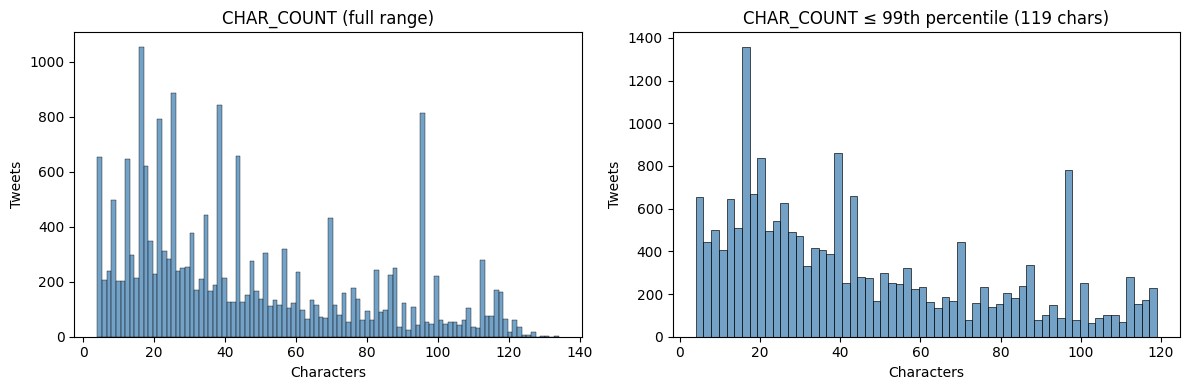

count    20000.000000
mean        45.809600
std         32.303924
min          4.000000
25%         19.000000
50%         38.000000
75%         70.000000
max        134.000000
Name: CHAR_COUNT, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['CHAR_COUNT'], bins=100, kde=False, ax=axes[0], color='steelblue')
axes[0].set_title('CHAR_COUNT (full range)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Tweets')

p99 = float(df['CHAR_COUNT'].quantile(0.99))
subset = df.loc[df['CHAR_COUNT'] <= p99, 'CHAR_COUNT']
sns.histplot(subset, bins=60, kde=False, ax=axes[1], color='steelblue')
axes[1].set_title(f'CHAR_COUNT ≤ 99th percentile ({p99:.0f} chars)')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Tweets')

plt.tight_layout()
plt.show()

print(df['CHAR_COUNT'].describe())

In [9]:
df['CHAR_COUNT'].value_counts()

CHAR_COUNT
16     1055
96      728
39      645
26      628
21      611
       ... 
125       6
124       5
134       4
131       2
130       1
Name: count, Length: 126, dtype: int64

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=['EMOJI', 'TWEET', 'LINE_NUM'], errors='ignore').select_dtypes(
    include=['number', 'bool']
)
y = df['EMOJI']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)


AVG_WORD_LENGTH         0.232627
CHAR_COUNT              0.211715
CAPITAL_RATIO           0.190511
WORD_COUNT              0.132214
CAPITAL_LETTER_COUNT    0.091718
MENTION_COUNT           0.056383
IS_RETWEET              0.027007
HAS_EXCLAMATION_MARK    0.024154
HAS_QUESTION_MARK       0.020766
HAS_HASH                0.012906
dtype: float64

model

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier

COLS_TO_DROP = []

df.drop(columns=COLS_TO_DROP, inplace=True, errors='ignore')
# Load data
le = LabelEncoder()
y = le.fit_transform(df['EMOJI'])

# BERT sentence embeddings (384-dim for all-MiniLM-L6-v2)
print("Generating BERT embeddings...")
_st_model = SentenceTransformer('all-MiniLM-L6-v2')
X_bert = np.vstack(_st_model.encode(df['TWEET'].astype(str).tolist(), show_progress_bar=True))

# Metadata only
metadata_cols = (
    df.drop(columns=['EMOJI', 'TWEET'], errors='ignore')
    .select_dtypes(include=['number', 'bool'])
    .columns.tolist()
)
scaler = StandardScaler()
X_meta = scaler.fit_transform(df[metadata_cols])

idx_train, idx_test, y_train, y_test = train_test_split(
    np.arange(len(y)), y, test_size=0.2, random_state=42, stratify=y
)

# RF Classifier
def evaluate_model(X_name, X_features):
    print(f"\nTraining Model: {X_name}...")
    X_tr, X_te = X_features[idx_train], X_features[idx_test]
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_tr, y_train)
    preds = clf.predict(X_te)
    score = f1_score(y_test, preds, average='macro')
    print(f"{X_name} Macro F1-Score: {score:.4f}")
    return score, preds

# Metadata-only vs BERT-embedding RF (same train/test split)
score_meta, preds_meta = evaluate_model("Metadata (RF)", X_meta)
score_bert, preds_bert = evaluate_model("BERT (RF)", X_bert)

print("\n--- FINAL RESULTS (Metadata vs BERT) ---")
print(f"Metadata F1: {score_meta:.4f}")
print(f"BERT F1:     {score_bert:.4f}")

# Save failed cases to CSV for edge case analysis
bert_mis = pd.DataFrame(
    {
        'TWEET': df.iloc[idx_test]['TWEET'].astype(str).values,
        'true_emoji': le.inverse_transform(y_test),
        'pred_emoji': le.inverse_transform(preds_bert),
    }
)
bert_wrong = bert_mis[bert_mis['true_emoji'] != bert_mis['pred_emoji']]
_bert_mis_path = 'data/bert_rf_misclassified.csv'
bert_wrong.to_csv(_bert_mis_path, index=False)
print(
    f"\nBERT+RF misclassified: {len(bert_wrong)} / {len(idx_test)} test tweets -> {_bert_mis_path}"
)

meta_mis = pd.DataFrame(
    {
        'TWEET': df.iloc[idx_test]['TWEET'].astype(str).values,
        'true_emoji': le.inverse_transform(y_test),
        'pred_emoji': le.inverse_transform(preds_meta),
    }
)
meta_wrong = meta_mis[meta_mis['true_emoji'] != meta_mis['pred_emoji']]
_meta_mis_path = 'data/meta_rf_misclassified.csv'
meta_wrong.to_csv(_meta_mis_path, index=False)
print(
    f"Metadata+RF misclassified: {len(meta_wrong)} / {len(idx_test)} test tweets -> {_meta_mis_path}"
)


C:\Users\avina\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating BERT embeddings...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2590.29it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 625/625 [00:42<00:00, 14.69it/s]



Training Model: Metadata Only (RF)...
Metadata Only (RF) Macro F1-Score: 0.7368

Training Model: BERT Only (RF)...
BERT Only (RF) Macro F1-Score: 0.8816

Training Model: Combined BERT + Meta (RF)...
Combined BERT + Meta (RF) Macro F1-Score: 0.8776

--- FINAL RESULTS ---
Metadata F1: 0.7368
BERT F1:     0.8816
Combined F1: 0.8776

--- BERT+RF misclassified: 473 / 4000 test tweets ---

I really want Starbucks
  true=sob  pred=weary

Panda Express for breakfast, Denny's for lunch, subway for extra lunch and then Olive Garden for dinner
  true=sob  pred=weary

oh I bet
  true=weary  pred=sob

Damn
  true=sob  pred=weary

74) I bet he's waiting for this moment even though he looks nervous afterwards
  true=weary  pred=sob

need Starbucks
  true=sob  pred=weary

I want starbucks
  true=sob  pred=weary

Nooooo lol hang in there
  true=weary  pred=sob

I was at Subway and there was a visually impaired man in front of me. A guy goes "hey man! Long time no see"
  true=weary  pred=sob

I bet
  t

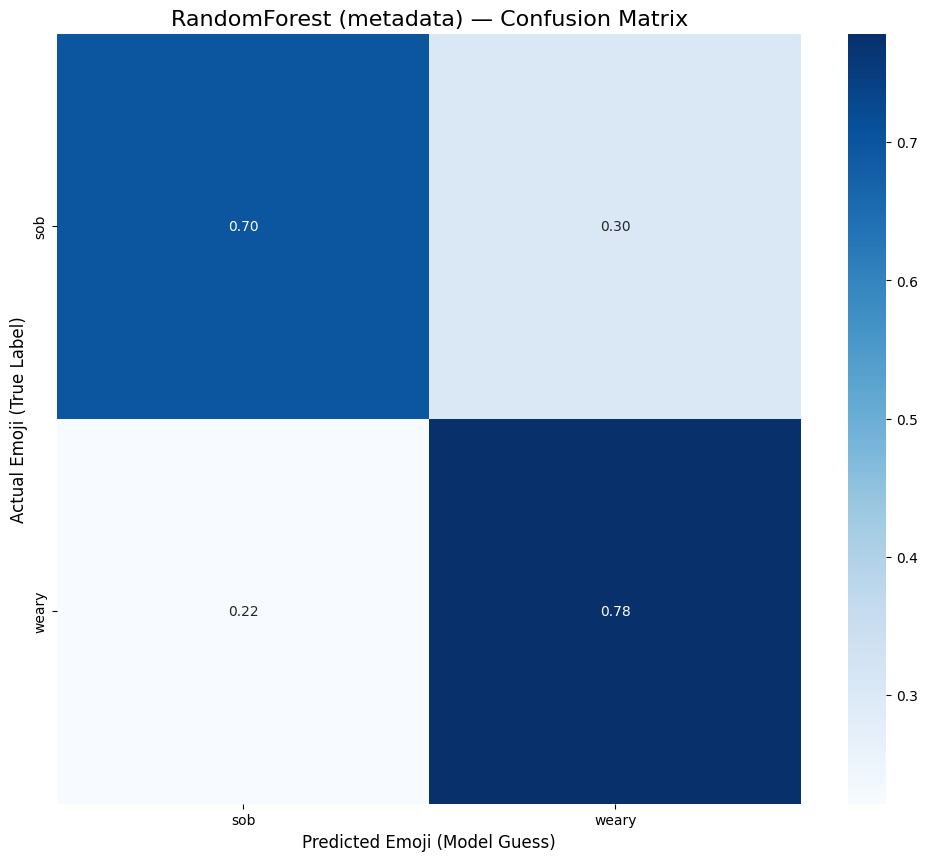

In [12]:
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# Metadata-only RandomForest (same split as main modeling cell)
_clf_cm = RandomForestClassifier(n_estimators=100, random_state=42).fit(
    X_meta[idx_train], y_train
)
_preds_cm = _clf_cm.predict(X_meta[idx_test])
cm = confusion_matrix(y_test, _preds_cm, normalize='true')

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)
plt.title('RandomForest (metadata) — Confusion Matrix', fontsize=16)
plt.ylabel('Actual Emoji (True Label)', fontsize=12)
plt.xlabel('Predicted Emoji (Model Guess)', fontsize=12)
plt.show()

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Metadata-only RandomForest (BERT path commented in main cell)
clf_meta = RandomForestClassifier(n_estimators=100, random_state=42).fit(
    X_meta[idx_train], y_train
)
preds_meta = clf_meta.predict(X_meta[idx_test])

# --- (commented) BERT RF + meta-vs-BERT disagreement analysis ---
# clf_bert = RandomForestClassifier(n_estimators=100, random_state=42).fit(
#     X_bert[idx_train], y_train
# )
# preds_bert = clf_bert.predict(X_bert[idx_test])
# disagreement_df = pd.DataFrame({
#     'Tweet': df['TWEET'].iloc[idx_test].values,
#     'Actual_Emoji': le.inverse_transform(y_test),
#     'Meta_Guess': le.inverse_transform(preds_meta),
#     'BERT_Guess': le.inverse_transform(preds_bert),
# })
# meta_wins = disagreement_df[
#     (disagreement_df['Actual_Emoji'] == disagreement_df['Meta_Guess'])
#     & (disagreement_df['Actual_Emoji'] != disagreement_df['BERT_Guess'])
# ]
# print(f"Found {len(meta_wins)} tweets where Metadata beat BERT.")
# for idx, row in meta_wins.head(20).iterrows():
#     print(f"\nActual: {row['Actual_Emoji']} | BERT Guessed: {row['BERT_Guess']}")
#     print(f"Tweet: {row['Tweet']}")